In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import matplotlib.patches as patches

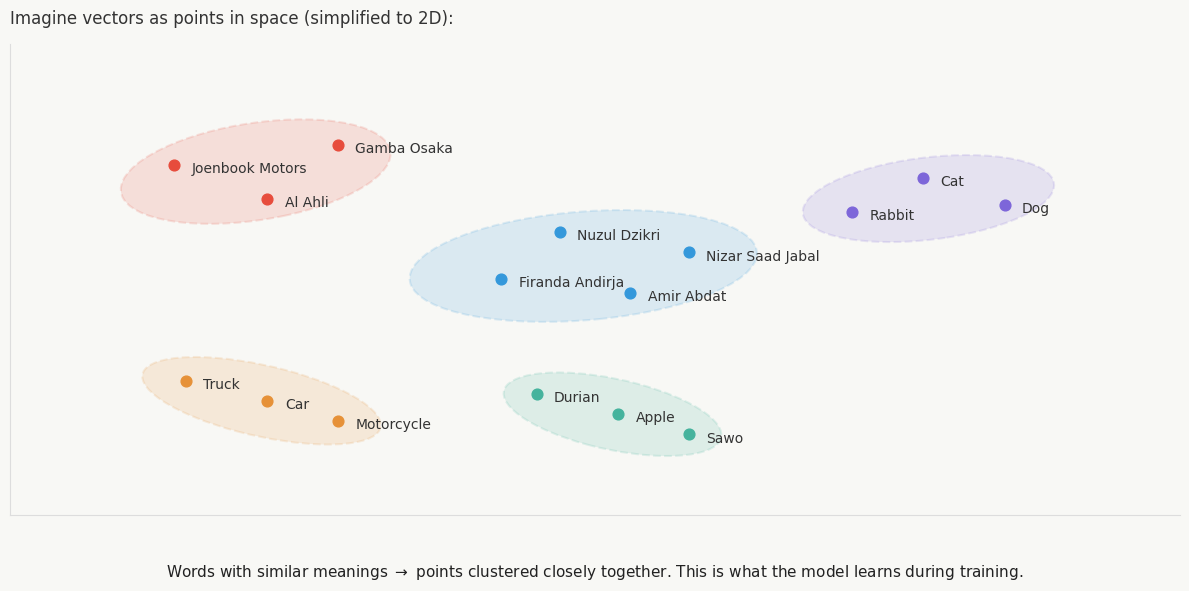

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

fig.patch.set_facecolor('#F8F8F5')
ax.set_facecolor('#F8F8F5')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#dddddd')
ax.spines['bottom'].set_color('#dddddd')
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

ax.set_xlim(0, 10)
ax.set_ylim(0, 7)

clusters = {
    'Vehicles': {
        'points': [(1.5, 2.0, 'Truck'), (2.2, 1.7, 'Car'), (2.8, 1.4, 'Motorcycle')],
        'color': '#E69138',
        'ellipse': ((2.15, 1.7), 2.2, 1.0, -25)
    },
    'Fruits': {
        'points': [(4.5, 1.8, 'Durian'), (5.2, 1.5, 'Apple'), (5.8, 1.2, 'Sawo')],
        'color': '#45B39D',
        'ellipse': ((5.15, 1.5), 2.0, 1.0, -25)
    },
    'Animals': {
        'points': [(7.2, 4.5, 'Rabbit'), (7.8, 5.0, 'Cat'), (8.5, 4.6, 'Dog')],
        'color': '#7D66D9',
        'ellipse': ((7.85, 4.7), 2.2, 1.2, 15)
    },
    'Football_Clubs': {
        'points': [(1.4, 5.2, 'Joenbook Motors'), (2.2, 4.7, 'Al Ahli'), (2.8, 5.5, 'Gamba Osaka')],
        'color': '#E74C3C',
        'ellipse': ((2.1, 5.1), 2.4, 1.4, 20)
    },
    'Asatidz': {
        'points': [(4.2, 3.5, 'Firanda Andirja'), (4.7, 4.2, 'Nuzul Dzikri'), (5.3, 3.3, 'Amir Abdat'), 
                   (5.8, 3.9, 'Nizar Saad Jabal')],
        'color': '#3498DB',
        'ellipse': ((4.9, 3.7), 3.0, 1.6, 10)
    }
}

for name, data in clusters.items():
    ex, ey, ew, eh, e_angle = data['ellipse'][0][0], data['ellipse'][0][1], data['ellipse'][1], data['ellipse'][2], data['ellipse'][3]
    ellipse = Ellipse((ex, ey), ew, eh, angle=e_angle, facecolor=data['color'], alpha=0.15, linestyle='--', edgecolor=data['color'], linewidth=1.5)
    ax.add_patch(ellipse)
    
    for pt in data['points']:
        ax.scatter(pt[0], pt[1], color=data['color'], s=60, zorder=3)
        ax.text(pt[0] + 0.15, pt[1] - 0.05, pt[2], fontsize=10, color='#333333', va='center')

ax.text(0, 7.3, "Imagine vectors as points in space (simplified to 2D):", fontsize=12, color='#333333')


footer_text = "Words with similar meanings $\\rightarrow$ points clustered closely together. This is what the model learns during training."
ax.text(5, -0.9, footer_text, ha='center', fontsize=11, color='#222222')

plt.tight_layout()
plt.show()

> What is Embedding?
- computer dont unstand word at all, it just unstand numbers. So each words changed into set of numbers this is what embedding means. Remember not just 1 number but a set numbers (vector) 

# Dot product

its first approach to check similarrity
- how to calculate? simple just multiple each pair of numbers and sum all
    - a = embedding of durian => [0.8,0.1,0.9]
    - b = embedding of mango => [0.2,0.8,0.7]
    - dot(a,b) = (0.8x0.2)+(0.1x0.8)+(0.9x0.7) = 1.3 <- the number big = well simillar
- but issues arise here, dot product rely on norm of vector, not only the direction. If the norm is long means always have big number despite the direction is not. It like person talk with scream not necessarily right wkwk.

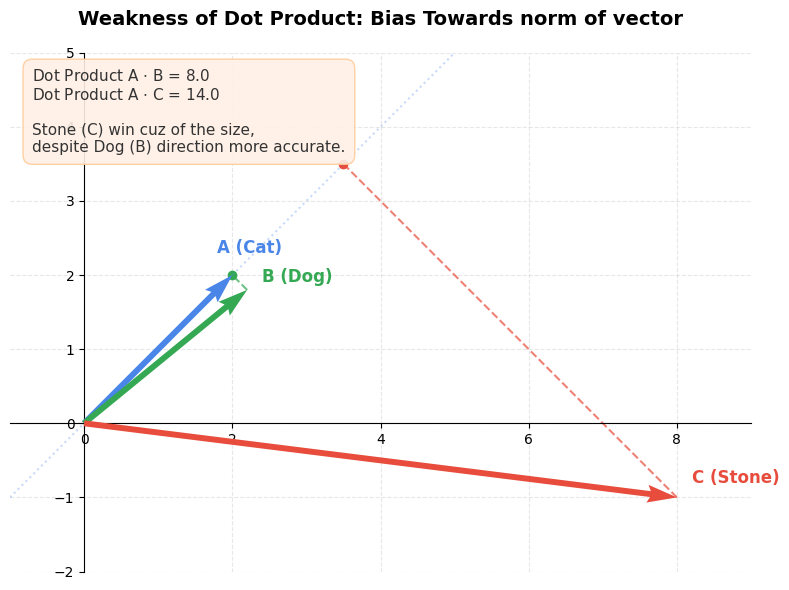

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.set_xlim(-1, 9)
ax.set_ylim(-2, 5)
ax.set_aspect('equal')
ax.grid(True, linestyle='--', alpha=0.3)

Ax, Ay = 2, 2
Bx, By = 2.2, 1.8
Cx, Cy = 8, -1

ax.quiver(0, 0, Ax, Ay, angles='xy', scale_units='xy', scale=1, color='#4A86E8', width=0.008, zorder=3)
ax.quiver(0, 0, Bx, By, angles='xy', scale_units='xy', scale=1, color='#34A853', width=0.008, zorder=3)
ax.quiver(0, 0, Cx, Cy, angles='xy', scale_units='xy', scale=1, color='#E74C3C', width=0.008, zorder=3)

mag_A_sq = Ax**2 + Ay**2
dot_AB = Ax*Bx + Ay*By
dot_AC = Ax*Cx + Ay*Cy

proj_B_x = (dot_AB / mag_A_sq) * Ax
proj_B_y = (dot_AB / mag_A_sq) * Ay
proj_C_x = (dot_AC / mag_A_sq) * Ax
proj_C_y = (dot_AC / mag_A_sq) * Ay

ax.plot([Bx, proj_B_x], [By, proj_B_y], linestyle='--', color='#34A853', alpha=0.7, lw=1.5)
ax.plot([Cx, proj_C_x], [Cy, proj_C_y], linestyle='--', color='#E74C3C', alpha=0.7, lw=1.5)

ax.plot(proj_B_x, proj_B_y, marker='o', color='#34A853', markersize=6)
ax.plot(proj_C_x, proj_C_y, marker='o', color='#E74C3C', markersize=6)

ax.plot([-1, 9], [-1, 9], linestyle=':', color='#4A86E8', alpha=0.3)

ax.text(Ax - 0.2, Ay + 0.3, "A (Cat)", color='#4A86E8', fontweight='bold', fontsize=12)
ax.text(Bx + 0.2, By + 0.1, "B (Dog)", color='#34A853', fontweight='bold', fontsize=12)
ax.text(Cx + 0.2, Cy + 0.2, "C (Stone)", color='#E74C3C', fontweight='bold', fontsize=12)

info_text = (
    f"Dot Product A $\\cdot$ B = {dot_AB:.1f}\n"
    f"Dot Product A $\\cdot$ C = {dot_AC:.1f}\n\n"
    f"Stone (C) win cuz of the size,\n"
    f"despite Dog (B) direction more accurate."
)
props = dict(boxstyle='round,pad=0.6', facecolor='#fff0e6', alpha=0.9, edgecolor='#ffcc99')
ax.text(0.03, 0.97, info_text, transform=ax.transAxes, fontsize=11, verticalalignment='top', bbox=props, color='#333333')

plt.title("Weakness of Dot Product: Bias Towards norm of vector", pad=20, fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

## Cosine Similarity

here we also measure the direction not the norm
- issue with dot(a,b) influenced by norm vector, the solution addressed by cosine sim is normalize first -> all norm vector = 1 
    - then dot product cosine_sim(a,b) = $\frac{dot(a,b)} {|a||b|}$ divide by each norm so the result always in range of -1 til 1
    - 1 = similar
    - 0 = perpendicular/unrelated
    - -1 = opposite (semantically different)
- cosine sim measure angle of 2 arrows, not just how long the arrows. 2 words can differently ...